In [7]:
import os

data_dir = './data/'

# List the contents of the extracted directory
print(f"Contents of '{data_dir}':")
for root, dirs, files in os.walk(data_dir):
    level = root.replace(data_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Contents of './data/':
/
Testing/
    notumor/
        Te-no_366.jpg
        Te-no_183.jpg
        Te-no_37.jpg
        Te-no_363.jpg
        Te-no_140.jpg
        Te-no_310.jpg
        Te-no_29.jpg
        Te-no_159.jpg
        Te-no_390.jpg
        Te-no_229.jpg
        Te-no_24.jpg
        Te-no_389.jpg
        Te-no_300.jpg
        Te-no_186.jpg
        Te-no_203.jpg
        Te-no_306.jpg
        Te-no_132.jpg
        Te-no_339.jpg
        Te-no_142.jpg
        Te-no_382.jpg
        Te-no_373.jpg
        Te-no_268.jpg
        Te-no_111.jpg
        Te-no_121.jpg
        Te-no_261.jpg
        Te-no_108.jpg
        Te-no_312.jpg
        Te-no_78.jpg
        Te-no_318.jpg
        Te-no_77.jpg
        Te-no_360.jpg
        Te-no_20.jpg
        Te-no_138.jpg
        Te-no_176.jpg
        Te-no_247.jpg
        Te-no_55.jpg
        Te-no_33.jpg
        Te-no_399.jpg
        Te-no_45.jpg
        Te-no_345.jpg
        Te-no_328.jpg
        Te-no_301.jpg
        Te-no_394.jpg
        Te-no_24

In [6]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths
base_dir = './data'
train_dir = os.path.join(base_dir, 'Training')
test_dir = os.path.join(base_dir, 'Testing')

# Image dimensions
IMG_WIDTH = 150
IMG_HEIGHT = 150
BATCH_SIZE = 32

# Data augmentation and preprocessing for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Preprocessing for test data (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches of 32 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical' # For multi-class classification
)

# Flow test images in batches of 32 using test_datagen generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Keep data in order for evaluation
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dropout(0.5), # Add dropout for regularization
    Dense(512, activation='relu'),
    Dense(4, activation='softmax') # 4 classes: no_tumor, glioma, meningioma, pituitary
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,035,716 (72.62 MB)

 Trainable params: 19,035,716 (72.62 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
EPOCHS = 3# You can adjust this number

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE
)

Epoch 1/3
175/175 ━━━━━━━━━━━━━━━━━━━━ 419s 2s/step - accuracy: 0.5561 - loss: 1.0095 - val_accuracy: 0.5944 - val_loss: 1.3069
Epoch 2/3
175/175 ━━━━━━━━━━━━━━━━━━━━ 408s 2s/step - accuracy: 0.6459 - loss: 0.8400 - val_accuracy: 0.5487 - val_loss: 1.6396
Epoch 3/3
175/175 ━━━━━━━━━━━━━━━━━━━━ 408s 2s/step - accuracy: 0.6996 - loss: 0.7268 - val_accuracy: 0.5800 - val_loss: 1.4453


## Model Evaluation

In [11]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 550ms/step - accuracy: 0.5800 - loss: 1.4453
Test Loss: 1.4453
Test Accuracy: 0.5800


## Visualize Training History

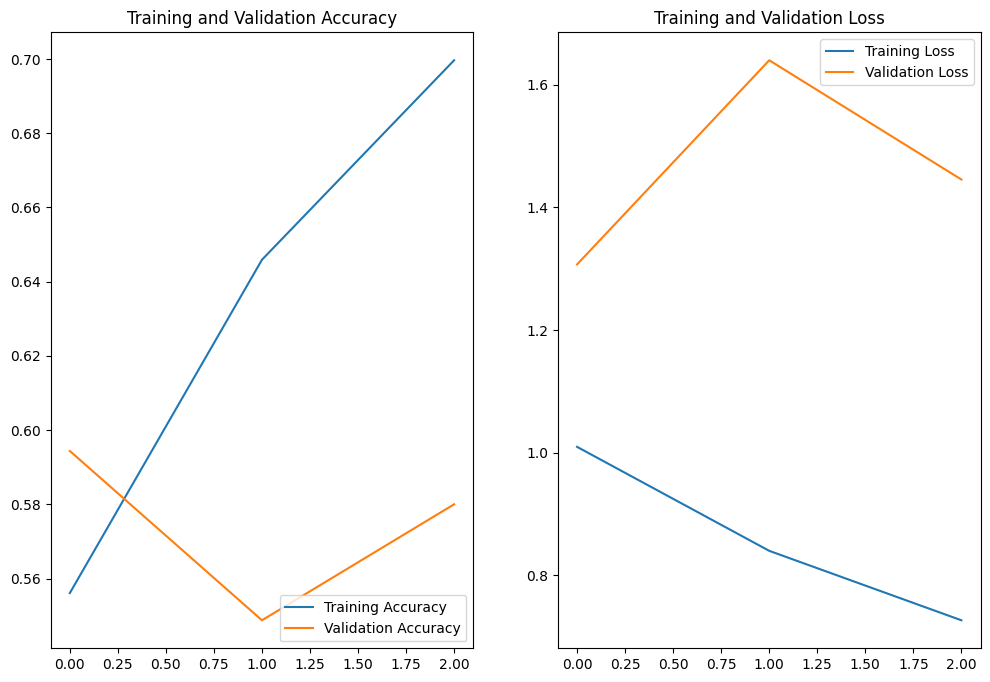

In [12]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [33]:
model.save('brain_tumor_model.h5')
print('Model saved as brain_tumor_model.h5')

Model saved as brain_tumor_model.h5


Now, let's modify `app.py` to include file upload and prediction functionality.

In [42]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import io
import pandas as pd # Import pandas for st.bar_chart

# Set Streamlit page configuration
st.set_page_config(
    page_title="Brain Tumor Detection Dashboard",
    page_icon="🧠",
    layout="centered", # Can be "wide"
    initial_sidebar_state="expanded",
)

# Load the trained model
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model('brain_tumor_model.h5')
    return model

# Define image dimensions and class names
IMG_WIDTH = 150
IMG_HEIGHT = 150
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary'] # Ensure this matches your training order

# --- Sidebar ---
st.sidebar.title("About the App")
st.sidebar.markdown(
    "This application uses a Convolutional Neural Network (CNN) to detect "
    "brain tumors from MRI images. It can classify images into four categories: "
    "glioma, meningioma, pituitary, or no tumor."
)
st.sidebar.markdown("---")
st.sidebar.markdown("### Model Details")
st.sidebar.text(f"Image Size: {IMG_WIDTH}x{IMG_HEIGHT}")
st.sidebar.text(f"Classes: {', '.join(CLASS_NAMES)}")

# --- Main Page ---
st.title('🧠 Brain Tumor Detection Dashboard')
st.markdown("Upload an MRI image below to get an instant prediction.")
st.write("---") # Visual separator

# Load model here after page config and sidebar to avoid reloading
model = load_model()

uploaded_file = st.file_uploader("## Upload MRI Image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    st.subheader("Uploaded Image")
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption='MRI Image', use_column_width=True) # width parameter is preferred over use_column_width
    st.write("") # Add some space

    if st.button('✨ Get Prediction'):
        with st.spinner('Making prediction...'):
            # Preprocess the image
            img_array = image.resize((IMG_WIDTH, IMG_HEIGHT))
            img_array = np.array(img_array)
            img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
            img_array = img_array / 255.0 # Rescale image

            # Make prediction
            predictions = model.predict(img_array)
            score = tf.nn.softmax(predictions[0])
            predicted_class_index = np.argmax(score)
            predicted_class = CLASS_NAMES[predicted_class_index]
            confidence = np.max(score) * 100

            st.success(f"### Prediction: **{predicted_class.upper()}**")
            st.info(f"Confidence: **{confidence:.2f}%**")

            st.write("---")
            st.subheader("Probability Distribution")

            # Create a DataFrame for the bar chart
            prob_df = pd.DataFrame({
                'Class': CLASS_NAMES,
                'Probability': score * 100 # Convert to percentage
            })
            # Sort for better visualization
            prob_df = prob_df.sort_values(by='Probability', ascending=False)

            st.bar_chart(prob_df.set_index('Class'))
            st.markdown("---")
            st.markdown("*(Disclaimer: This is an experimental model and should not be used for medical diagnosis.)*")
else:
    st.info("Awaiting image upload. Please upload an MRI image to proceed with the prediction.")


Overwriting app.py


In [49]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import io
import pandas as pd # Import pandas for st.bar_chart

# Set Streamlit page configuration
st.set_page_config(
    page_title="Brain Tumor Detection Dashboard",
    page_icon="🧠",
    layout="centered", # Can be "wide"
    initial_sidebar_state="expanded",
)

# Load the trained model
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model('brain_tumor_model.h5')
    return model

# Define image dimensions and class names
IMG_WIDTH = 150
IMG_HEIGHT = 150
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary'] # Ensure this matches your training order

# --- Sidebar ---
st.sidebar.title("About the App")
st.sidebar.markdown(
    "This application uses a Convolutional Neural Network (CNN) to detect "
    "brain tumors from MRI images. It can classify images into four categories: "
    "glioma, meningioma, pituitary, or no tumor."
)
st.sidebar.markdown("--- Kishan")
st.sidebar.markdown("### About Me")
st.sidebar.markdown("**ARAVIND INISH**")
st.sidebar.markdown("AI & Data Science Student | Future Tech Innovator | Finance & Investment Enthusiast | Exploring Business, Healthcare Technologies, and Robotics")
st.sidebar.markdown("### Model Details")
st.sidebar.text(f"Image Size: {IMG_WIDTH}x{IMG_HEIGHT}")
st.sidebar.text(f"Classes: {', '.join(CLASS_NAMES)}")

# --- Main Page ---
st.title('🧠 Brain Tumor Detection Dashboard')
st.markdown("Upload an MRI image below to get an instant prediction.")
st.write("---") # Visual separator

# Load model here after page config and sidebar to avoid reloading
model = load_model()

uploaded_file = st.file_uploader("## Upload MRI Image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    st.subheader("Uploaded Image")
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption='MRI Image', use_column_width=True) # width parameter is preferred over use_column_width
    st.write("") # Add some space

    if st.button('✨ Get Prediction'):
        with st.spinner('Making prediction...'):
            # Preprocess the image
            img_array = image.resize((IMG_WIDTH, IMG_HEIGHT))
            img_array = np.array(img_array)
            img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
            img_array = img_array / 255.0 # Rescale image

            # Make prediction
            predictions = model.predict(img_array)
            score = tf.nn.softmax(predictions[0])
            predicted_class_index = np.argmax(score)
            predicted_class = CLASS_NAMES[predicted_class_index]
            confidence = np.max(score) * 100

            st.success(f"### Prediction: **{predicted_class.upper()}**")
            st.info(f"Confidence: **{confidence:.2f}%**")

            st.write("---")
            st.subheader("Probability Distribution")

            # Create a DataFrame for the bar chart
            prob_df = pd.DataFrame({
                'Class': CLASS_NAMES,
                'Probability': score * 100 # Convert to percentage
            })
            # Sort for better visualization
            prob_df = prob_df.sort_values(by='Probability', ascending=False)

            st.bar_chart(prob_df.set_index('Class'))
            st.markdown("---")
            st.markdown("*(Disclaimer: This is an experimental model and should not be used for medical diagnosis.)*")
else:
    st.info("Awaiting image upload. Please upload an MRI image to proceed with the prediction.")

Overwriting app.py


Now that `app.py` has been updated, you need to restart the Streamlit server to see the changes. Execute the following cells to run the app again with `ngrok`.

In [35]:
from pyngrok import ngrok

# Terminate any existing ngrok tunnels
ngrok.kill()

# Open a ngrok tunnel to port 8501 (Streamlit's default port)
# Make sure your NGROK_AUTH_TOKEN is set in Colab secrets
# from google.colab import userdata
# NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
# ngrok.set_auth_token(NGROK_AUTH_TOKEN)

public_url = ngrok.connect(addr='8501', proto='http')
print(f"Streamlit App URL: {public_url}")

Streamlit App URL: NgrokTunnel: "https://foraminate-anders-uncovetous.ngrok-free.dev" -> "http://localhost:8501"


In [36]:
!streamlit run app.py

2026-07-16 16:27:32.114 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.138.9.231:8501



  Stopping...


In [13]:
import sys

# Install streamlit
!{sys.executable} -m pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 63.4 MB/s eta 0:00:00


In [28]:
import sys

# Install ngrok
!{sys.executable} -m pip install pyngrok

Next, let's create a simple Streamlit application file (`app.py`). This example will just display a title and a text message. In a real application, you would load your trained model here and use it to make predictions.

In [14]:
%%writefile app.py
import streamlit as st

st.title('Brain Tumor Detection App')
st.write('Welcome to the brain tumor detection application!')
st.write('This is a placeholder. You can integrate your model here to make predictions.')


Writing app.py


To run your Streamlit application, execute the following command in a new cell. Note that you'll need to open the external URL provided by Colab to view the app.

Alternatively, you can navigate to the 'port' section in the left panel and configure port forwarding for `8501` to view it directly within Colab.

In [23]:
from pyngrok import ngrok
ngrok.set_auth_token("3AbwaW53yv021tNxAXrWJumLaDB_7ooi3CHcXxwCCt7XaTCXX")

In [51]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://foraminate-anders-uncovetous.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!streamlit run app.py



2026-07-16 16:59:38.144 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.138.9.231:8501

2026-07-16 16:59:50.095861: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2026-07-16 17:00:21.932 The `use_column_width` parameter has been deprecated and will be removed in a future release. Please utilize the `width` parameter instead.
2026-07-16 17:00:41.812 The `use_column_width` parameter has been deprecated and will be removed in a future release. Please utilize the `width` parameter instead.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


In [52]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://foraminate-anders-uncovetous.ngrok-free.dev" -> "http://localhost:8501"
